# Response to Reviewers

_Dataset:_ Supplementary data for Megill and Grewe (2025): "Investigating the limiting aircraft design-dependent and environmental factors of persistent contrail formation".

_Authors:_

- Liam Megill (1, 2), https://orcid.org/0000-0002-4199-6962   
- Volker Grewe (1, 2), https://orcid.org/0000-0002-8012-6783  

_Affiliation (1)_: Deutsches Zentrum für Luft- und Raumfahrt (DLR), Institut für Physik der Atmosphäre, Oberpfaffenhofen, Germany

_Affiliation (2)_: Delft University of Technology (TU Delft), Faculty of Aerospace Engineering, Section Aircraft Noise and Climate Effects (ANCE), Delft, The Netherlands

_Corresponding author_: Liam Megill, liam.megill@dlr.de

_doi_: https://doi.org/10.5194/egusphere-2024-3398

---


### Summary
This notebook creates the figures made when responding to the reviewers of the linked article.

### Inputs
- `limfac` module: https://github.com/liammegill/contrail-limiting-factors
- `data/processed/limfac/nb_limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc`: Non-boundary limiting factor results for all aircraft and RHi enhancements.
- `data/processed/limfac/vert_limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc`: Vertical limiting factor boundary results for all aircraft and RHi enhancements.
- `data/processed/limfac/limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc`: Horizontal limiting factor boundary results for all aircraft and RHi enhancements.
- `data/processed/ppcf/fit_res.pickle`: Data for climatological potential persistent contrail formation fits.

### Outputs
- Figures for peer review discussion.

---

### Copyright

Copyright © 2025 Liam Megill

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys

project_dir = ""  # set top-level directory path
processed_data_dir = project_dir + "data/processed/limfac/"
sys.path.append(project_dir)
import limfac as lf

colors = ['#2271B2', '#3DB7E9', '#F748A5', '#359B73', '#D55E00', '#E69F00', '#F0E442']

# open dataset
dsnb = xr.open_dataset(f"{processed_data_dir}nb_limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc")  # cell limiting factors
dsv = xr.open_dataset(f"{processed_data_dir}vert_limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc")  # vertical ppcf region boundaries
dsh = xr.open_dataset(f"{processed_data_dir}limfac_allAC_rmS_ERA5_GRIB_allcorr_v4.nc")  # horizontal ppcf region boundaries

with open(f'{project_dir}data/processed/ppcf/fit_res.pickle', 'rb') as fp:
    fit_res = pickle.load(fp)

dsh

## Climatological data

Here, we analyse whether using 10 % of the data in the 2010 decade is sufficient. We compare the potential persistent contrail formation $p_{pcf}$ from the limiting factors analysis with the fits found for $p_{pcf}$ vs. $G$ (which uses 100 % of the data).

In [ ]:
fig, ax = plt.subplots()
x_data_plt = np.arange(0.2, 25.2, 0.2)

for i_lvl, lvl in enumerate(dsh.level.values):
    # plot maxg results
    if i_lvl < 5:
        y1 = lf.logistic_gen(x_data_plt, *fit_res[lvl]["params_1"])
        y2 = lf.logistic(x_data_plt, *fit_res[lvl]["params_2"])
        y_comb = y1 + y2
    else:
        y_comb = lf.logistic_gen(x_data_plt, *fit_res[lvl]["params"])
    ax.plot(x_data_plt, y_comb, ls="--", c=colors[i_lvl], label="", lw=1.0, zorder=2)

    for ac_id in dsh.AC.values:
        ac = xr.load_dataset(project_dir+"data/aircraft_specs_v3.nc").sel(id=ac_id)
        # plot limfac results
        g = lf.calc_sac_slope(
            ac.fuel, ac.cp, lvl*100., ac.eps, ac.EI_H2O, ac.eta, ac.Q, ac.R,
            0.4, ac.dH_mol, ac.cp_mol
        )
        ds_i = dsh.sel(corr="uncor", AC=ac_id, level=lvl).ppcf
        ax.scatter(g, ds_i.values.mean(), c=colors[i_lvl], zorder=3)

ax.set_xlabel("Mixing line slope $G$ [Pa/K]")
ax.set_ylabel("Potential persistent contrail formation $p_{PCF}$ [-]")
ax.set_xlim([0, 8])
ax.set_ylim([0, 0.1])

# create custom legend
from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], color=color, lw=5) for color in colors]
legend_lines.append(Line2D([], [], c="k", ls="None", marker="o"))
legend_lines.append(Line2D([0], [0], c="k", lw=1, ls="--"))
legend_labels = np.append([f"{pl} hPa" for pl in dsh.level.values.astype(int)], ["10 % data", "100 % data"])
ax.legend(legend_lines, legend_labels, loc="lower right", ncol=2, handlelength=2)

## Mixing line slope

Now, we compare the old droplet formation method with the new one. With the old methodology, we were unable to capture the lower "effective freezing temperature" found by Bier et al. (2022, 2024) for both conventional but notably for hydrogen combustion aircraft. The new methodology considers that the plume must be _concurrently_ supersaturated with respect to water and below the homogeneous freezing temperature. It does this by modifying the definition of $T_{max}$ to be equal to 235.15 K when it would otherwise be greater than 235.15 K. See the response to the reviewers and the article for more information.

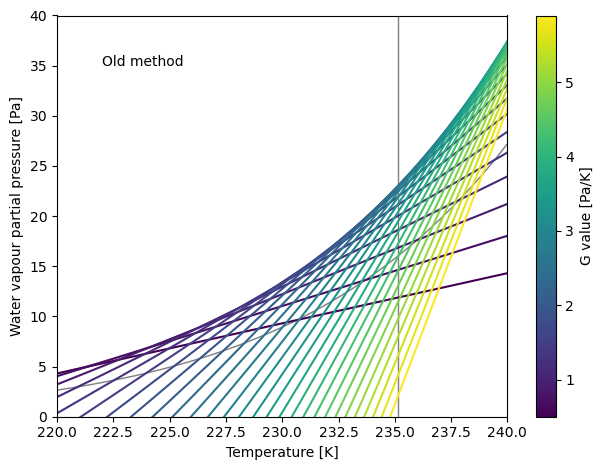

In [6]:
# old method
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# project directories
project_dir = "/work/bd1062/b309257/contrail-limiting-factors/"  # set top-level directory path
sys.path.append(project_dir)
import limfac as lf

fig, ax = plt.subplots()

t_arr = np.arange(200., 246., 0.01)
ppi_sat_arr = lf.e_sat_ice(t_arr)
pplq_sat_arr = lf.e_sat_water(t_arr)
ax.plot(t_arr, ppi_sat_arr, color="tab:gray", linewidth=1)
ax.plot(t_arr, pplq_sat_arr, color="tab:gray", linewidth=1)
ax.axvline(235.15, color="tab:gray", linewidth=1)

# loop over G
g_arr = np.arange(0.5, 6.0, 0.2)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=g_arr.min(), vmax=g_arr.max())

for g in g_arr:

    if g <= 2.0:
        T_max = lf.calc_single_t_max(0, g)
    else:
        T_max = lf.calc_single_t_max(1, g)

    pplq_T_max = lf.e_sat_water(T_max)
    y_intersect = pplq_T_max - g * T_max

    def f(T):
        return T * g + y_intersect
    
    color = cmap(norm(g))
    ax.plot(t_arr, f(t_arr), color=color)

# add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("G value [Pa/K]")

# set axis labels
ax.annotate("Old method", xy=(222, 35))
ax.set_xlim([220, 240])
ax.set_ylim([0, 40])
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Water vapour partial pressure [Pa]")
fig.tight_layout()

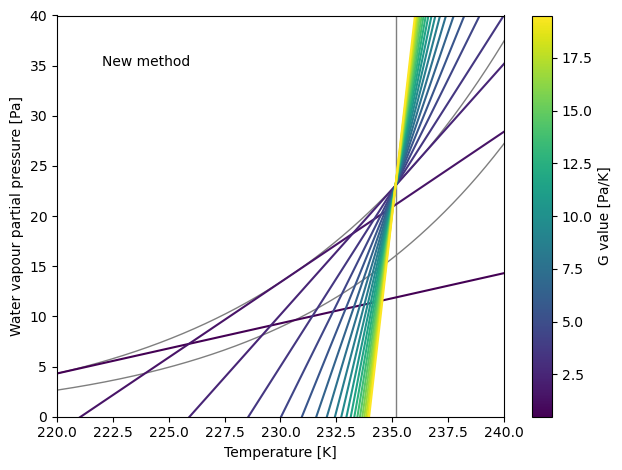

In [4]:
# new method
fig, ax = plt.subplots()

t_arr = np.arange(200., 246., 0.01)
ppi_sat_arr = lf.e_sat_ice(t_arr)
pplq_sat_arr = lf.e_sat_water(t_arr)
ax.plot(t_arr, ppi_sat_arr, color="tab:gray", linewidth=1)
ax.plot(t_arr, pplq_sat_arr, color="tab:gray", linewidth=1)
ax.axvline(235.15, color="tab:gray", linewidth=1)

# loop over G
g_arr = np.arange(0.5, 20.0, 1)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=g_arr.min(), vmax=g_arr.max())

for g in g_arr:

    if g <= 2.0:
        T_max = lf.calc_single_t_max(0, g)
    else:
        T_max = lf.calc_single_t_max(1, g)

    if T_max < 235.15:
        pplq_T_max = lf.e_sat_water(T_max)
        y_intersect = pplq_T_max - g * T_max
    else:
        pplq_235 = lf.e_sat_water(235.15)
        y_intersect = pplq_235 - g * 235.15

    def f(T):
        return T * g + y_intersect
    
    color = cmap(norm(g))
    ax.plot(t_arr, f(t_arr), color=color)

# add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("G value [Pa/K]")

# set axis labels
ax.annotate("New method", xy=(222, 35))
ax.set_xlim([220, 240])
ax.set_ylim([0, 40])
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Water vapour partial pressure [Pa]")
fig.tight_layout()